In [73]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torch.optim.lr_scheduler import StepLR

In [74]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
normal_trans=transforms.Compose([
    transforms.Resize((128,128)),    
    transforms.ToTensor()
])

aug_trans = transforms.Compose([
    transforms.Resize((128,128)), 
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

In [75]:
DATA_DIR = r'C:\Users\MJ\Desktop\seg'
model_algo="alexnet"


In [76]:
#建立dataset class
class ImageDataset(Dataset):
    def __init__(self, root,trans1,trans2,decision_mode=False):
        super().__init__()
        self.images = ImageFolder(root=root)
        self.classes = self.images.class_to_idx.items()
        self.flag= [True] * len(self.images)
        self.decision_mode=decision_mode
        self.normal_trans = trans1
        self.aug_trans = trans2
        self.sum=0
    def __len__(self):
        return len(self.images)
   
    def __getitem__(self,idx):
        image, label=self.images[idx]

        if(self.flag[idx]==True):
            image=self.normal_trans(image)
        else:
            image=self.aug_trans(image)
            self.sum+=1

        if(self.decision_mode==True):
            label=int(self.flag[idx])
            
        return image,label,idx
    
    def update_flag(self, idx):
        self.flag[idx] = False
    

In [77]:
#讀取資料且切分資料為train、valid、test

trainset=ImageDataset(DATA_DIR+"/seg_train",normal_trans,aug_trans,decision_mode=False)
validset=ImageDataset(DATA_DIR+"/seg_test",normal_trans,aug_trans,decision_mode=False)

train_size = len(trainset)
valid_size = len(validset)

# trainset, validset, testset = random_split(images, (train_size, valid_size, test_size))


In [78]:
# create data loaders
batch_size = 64 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()
idx2class = {v: k for k, v in trainset.classes}

In [79]:
#建立模型框架
def model_create(model_algo,data_name):
    model = getattr(models,model_algo)(weights=True)
    for param in model.features.parameters():
        param.requires_grad = False
    if(data_name=='decision'):
        class_number=2
    else:
        class_number=len(trainset.classes)

    if(model_algo=='googlenet' or model_algo=='resnet18' ):
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, class_number)
    else :
        num_ftrs = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(num_ftrs,class_number)
    
    return model

In [80]:
#模型表現
def evaluate_model(model,data_dl,size):
        model.to(device)
        ######################    
        # validate the model #
        ######################
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
                model.eval()   

                for data, target,idx in data_dl:

                        data,target=data.to(device),target.to(device)
                        out= model(data)
                        _, y_pred_tag = torch.max(out, dim = 1)
                        loss = criterion(out, target)
                        
                        flat_true.extend(target.cpu().numpy())
                        flat_pred.extend(y_pred_tag.cpu().numpy())

                        total_loss+= loss.item()*data.size(0)
                        correct=torch.sum(y_pred_tag == target).item()
                        accu += correct      

                total_loss=total_loss/size
                accu=accu/size
        confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
        return total_loss,accu,confusion_matrix_valid

In [81]:
    
def evaluate_model_TF(model,TorF):
    num=0
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
   
    with torch.no_grad():
            model_0.eval()   
            for data, target,idx in valid_dl:

                    data,target=data.to(device),target.to(device)
                    out_growth= model_0(data)
                    _, decision_tag = torch.max(out_growth, dim = 1)

                    for result,d,t in zip(torch.eq(target,decision_tag),data,target):
                            if (TorF == "T" and result.cpu().numpy()) or (TorF == "F" and not result.cpu().numpy()):
                                out = model(d.unsqueeze(0))
                                _, y_pred_tag = torch.max(out, dim = 1)
                                loss=criterion(out,t.unsqueeze(0))
                                num+=1
                        
                                total_loss+= loss.item()
                                correct=torch.sum(y_pred_tag == t).item()
                
                                accu += correct 
                                flat_true.extend(t.unsqueeze(0).cpu().numpy())
                                flat_pred.extend(y_pred_tag.cpu().numpy()) 

    valid_loss=total_loss/num
    valid_accu=accu/num                                  
    print(f"Model_{TorF} valid loss={valid_loss}, accu={valid_accu},sample_number={num}") 
    confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return valid_loss,valid_accu,confusion_matrix_valid

In [82]:

def evaluate_model_decision(model):
        correct=0
        flat_true=[]
        flat_pred=[]
        decision_valid_accu=0
        with torch.no_grad():
                model_0.eval()   
                for data, target,idx in valid_dl:

                        data,target=data.to(device),target.to(device)
                        out_growth= model_0(data)   #原始model
                        _, y_pred_tag = torch.max(out_growth, dim = 1)

                        out_predict= model(data)  #預測要用哪個model
                        _, predict = torch.max(out_predict, dim = 1)
        
                        for pred,result in zip(predict,torch.eq(target,y_pred_tag)):
                                if(result==pred):
                                        correct+=1
                                flat_true.append(result.cpu().numpy())
                                flat_pred.append(pred.cpu().numpy())

        decision_valid_accu=correct/valid_size

        print("decision_valid accu=",decision_valid_accu) 
        confusion_matrix_decision_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
        return  decision_valid_accu,confusion_matrix_decision_valid

In [83]:
#訓練模型
def trainer(epochs,model,criterion,optim,data_dl,data_name):
        train_accus=[]
        val_accus=[]
        best_val_accu = 0.0
        epochs_without_improvement = 0
        overfitting = 0
        patience=5

        for epoch in range(epochs):
                
                train_loss=0
                model.to(device)
                model.train()
                ###################
                # train the model #
                ###################
                for data, target,idx in data_dl:
                        
                        optim.zero_grad()
                        data,target=data.to(device),target.to(device)  #將data、target放到gpu上
                      
                        out = model(data)
                        # _, y_pred_tag = torch.max(out, dim = 1)  
                        
                        loss = criterion(out, target)
                        loss.backward()
                        optim.step()
                        # print(target)
                
                      
                train_loss,train_accu,_=evaluate_model(model,data_dl,len(data_dl.dataset))
                print(f"Epoch={epoch},train_loss={train_loss},train_accu={train_accu}")
                train_accus.append(train_accu)
                
                if(data_name=="T" or data_name=="F"):  
                        
                        val_loss,val_accu,_=evaluate_model_TF(model,data_name)
                elif(data_name=="decision"):
                        val_accu,_=evaluate_model_decision(model)
                else:
                        val_loss,val_accu,_=evaluate_model(model,valid_dl,valid_size)
                        print(f"Epoch={epoch},valid_loss={val_loss},valid_accu={val_accu}")

                val_accus.append(val_accu)
        
                # Early stopping
                if val_accu > best_val_accu:
                        best_val_accu = val_accu
                        epochs_without_improvement = 0
                        best_model=model
                # elif (train_accu-best_val_accu>0.02):
                #         overfitting += 1
                        
                else:
                        epochs_without_improvement += 1

                if epochs_without_improvement >= patience:
                        print("Early stopping!")
                        break
                elif overfitting >= patience:
                        print("Early stopping overfit!")
                        break
                
                torch.save(model, f"model_{model_algo}_{data_name}_{epoch}.pth")                
        plt.plot(train_accus,'-o')
        plt.plot(val_accus,'-o')

        plt.xlabel('epoch')
        plt.ylabel('Accuracy')
        plt.legend(['Train','Valid'])


        plt.show()
        return best_model
                

In [84]:
#將模型建立框架後並訓練
def model_train(model_algo,data_dl,data_name,epochs,class_weight=None):
    
    model=model_create(model_algo,data_name)
    if(data_name=="decision"):
        trainset.decision_mode=True
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4,weight_decay=1e-3)
        criterion = nn.CrossEntropyLoss(weight=class_weight)
        
        model=trainer(epochs,model,criterion,optim,data_dl,data_name)
        trainset.decision_mode=False
    else:
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4,weight_decay=1e-3)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,data_dl,data_name)
    torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model

In [85]:
# model_0=model_train(model_algo,train_dl,"0",20)
model_0 = torch.load(f'model_{model_algo}_0_2.pth')

In [86]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size)
train_loss,train_accu

(0.3661172030971688, 0.8685335613510047)

In [87]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size)
valid_loss,valid_accu

(0.3941374034881592, 0.8653333333333333)

In [88]:
#將資料切分成true and false
def split_data(model_0,data_dl):
    model_0.eval()
  
    indexF=[]
    indexT=[]
    with torch.no_grad():

        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            # print(y_pred_tag)
            for idx,t,tag in zip(idx,target,y_pred_tag):

                if(t==tag):
                    indexT.append(idx.cpu().numpy().item())
                    
                else:
                    indexF.append(idx.cpu().numpy().item())
                    trainset.update_flag(idx)
            
        torch.cuda.empty_cache() 
    return indexF,indexT

In [89]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
indexF,indexT=split_data(model_0,train_dl)

Fdataset=Subset(trainset, indexF)
Tdataset=Subset(trainset, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)


In [90]:
len(indexF),len(indexT)

(1845, 12189)

In [91]:
targets=[target for _,target,_ in trainset]
flag_counts=[len(indexF),len(indexT)]
total_sample=sum(flag_counts)
w=[total_sample / count for count in flag_counts] 
weights = [w[0]-2 if t == 0 else w[1] for t in targets]

w=torch.tensor(w).cuda()

In [92]:
sampler = WeightedRandomSampler(weights, len(trainset), replacement=True)
trainset.decision_mode=True
decision_dl = DataLoader(trainset, batch_size=64,sampler=sampler)
trainset.decision_mode=False

In [93]:
trainset.sum

1845

In [94]:
# trainset.decision_mode=True
# data=[data.numpy() for data ,_,_ in trainset]
# targets=[target for _,target,_ in trainset]
# trainset.decision_mode=False

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.5536152104400783,train_accu=0.6632464015961237
decision_valid accu= 0.5083333333333333
Epoch=1,train_loss=0.4789278538491764,train_accu=0.7045033490095483
decision_valid accu= 0.568
Epoch=2,train_loss=0.7256528001336506,train_accu=0.5877868034772695
decision_valid accu= 0.5056666666666667
Epoch=3,train_loss=0.39035870865979083,train_accu=0.7656405871455038
decision_valid accu= 0.6146666666666667
Epoch=4,train_loss=0.4187236150836306,train_accu=0.7544534701439362
decision_valid accu= 0.6436666666666667
Epoch=5,train_loss=0.41267505783767666,train_accu=0.7579449907367821
decision_valid accu= 0.6266666666666667
Epoch=6,train_loss=0.31957620955675575,train_accu=0.8202935727518883
decision_valid accu= 0.6976666666666667
Epoch=7,train_loss=0.32490079555736406,train_accu=0.8239276043893402
decision_valid accu= 0.6926666666666667
Epoch=8,train_loss=0.3179243607102797,train_accu=0.8244263930454611
decision_valid accu= 0.7073333333333334
Epoch=9,train_loss=0.2774994280436142

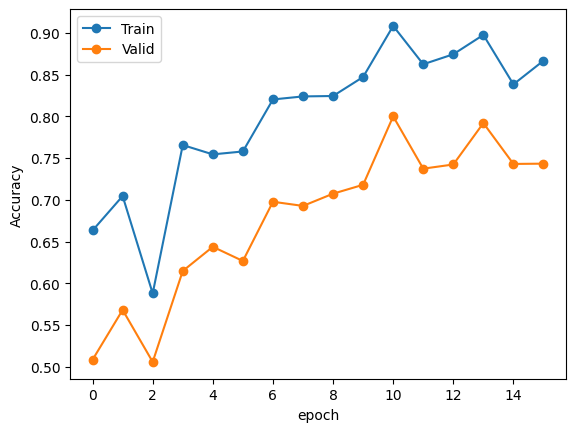

In [95]:
model_decision=model_train(model_algo,decision_dl,"decision",50,w)
# model_decision = torch.load(f'model_{model_algo}_decision.pth')

In [96]:
trainset.sum

59044

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.06572899115862874,train_accu=0.9748133563048651
Model_T valid loss=0.08888153856305776, accu=0.9707241910631741,sample_number=2596
Epoch=1,train_loss=0.057383988824315335,train_accu=0.9812946098941668
Model_T valid loss=0.09747669165066691, accu=0.9699537750385208,sample_number=2596
Epoch=2,train_loss=0.025110116762850476,train_accu=0.9936828287800475
Model_T valid loss=0.06793233242267567, accu=0.9780431432973806,sample_number=2596
Epoch=3,train_loss=0.023085102993067066,train_accu=0.9940930347034211
Model_T valid loss=0.05981203650060595, accu=0.9749614791987673,sample_number=2596
Epoch=4,train_loss=0.03499955627038819,train_accu=0.9885142341455411
Model_T valid loss=0.07704867223456546, accu=0.9714946070878274,sample_number=2596
Epoch=5,train_loss=0.021072708709268296,train_accu=0.9937648699647222
Model_T valid loss=0.07474725896109696, accu=0.9680277349768875,sample_number=2596
Epoch=6,train_loss=0.013605410766192084,train_accu=0.9973746820904094
Model_T valid 

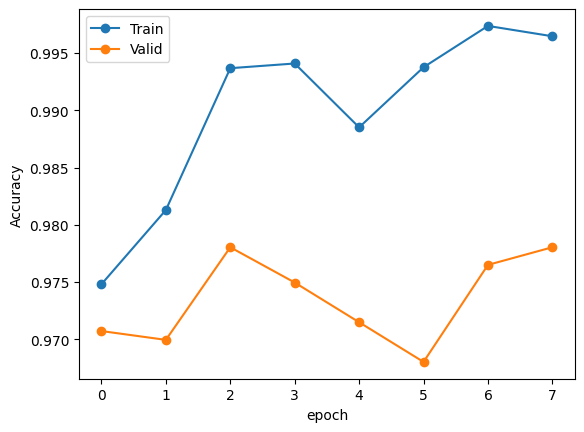

In [97]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,"T",20)
# model_T=torch.load(f'model_{model_algo}_T.pth')

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.982915815751404,train_accu=0.6205962059620597
Model_F valid loss=1.0896661804232857, accu=0.5792079207920792,sample_number=404
Epoch=1,train_loss=0.7584101918913162,train_accu=0.7149051490514905
Model_F valid loss=0.9378369716134402, accu=0.6262376237623762,sample_number=404
Epoch=2,train_loss=0.5918136053938207,train_accu=0.7902439024390244
Model_F valid loss=0.8439637094143649, accu=0.6683168316831684,sample_number=404
Epoch=3,train_loss=0.4704269721256039,train_accu=0.8552845528455284
Model_F valid loss=0.8422203695901214, accu=0.6831683168316832,sample_number=404
Epoch=4,train_loss=0.39407595489729386,train_accu=0.8818428184281842
Model_F valid loss=0.771839120556107, accu=0.7252475247524752,sample_number=404
Epoch=5,train_loss=0.2951479460650343,train_accu=0.926829268292683
Model_F valid loss=0.6926086403583384, accu=0.75,sample_number=404
Epoch=6,train_loss=0.28097939549422846,train_accu=0.924119241192412
Model_F valid loss=0.7020379480208347, accu=0.69801980

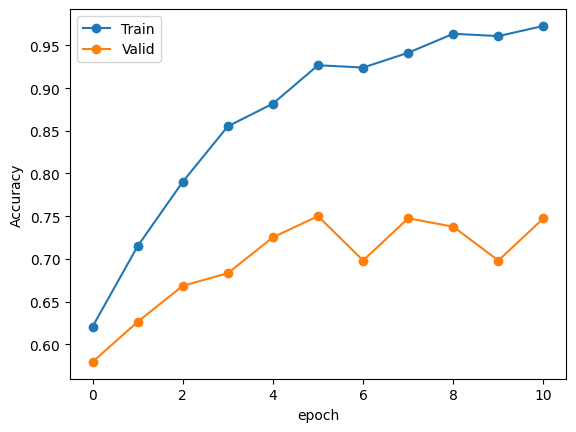

In [98]:
model_F=model_train(model_algo,Fdl,"F",50)
# model_F=torch.load(f'model_{model_algo}_F.pth')

In [100]:
torch.cuda.empty_cache()

In [101]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset))
T_loss,T_accu

(0.016334243616324098, 0.9964722290589876)

In [102]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset))
F_loss,F_accu

(0.13175820793885848, 0.9745257452574526)

In [103]:
trainset.decision_mode=True
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,train_size)
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"buildings":"False","forest":"True"}, index={"buildings":"False","forest":"True"})
trainset.decision_mode=False
decision_loss,decision_accu

(0.2538305000670533, 0.8695311386632464)

In [104]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model_TF(model_T,"T")
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model_TF(model_F,"F")


Model_T valid loss=0.06359896404235287, accu=0.9780431432973806,sample_number=2596
Model_F valid loss=0.7059868945897245, accu=0.7475247524752475,sample_number=404


In [105]:

decision_valid_accu,confusion_matrix_decision_valid=evaluate_model_decision(model_decision )
# confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})

decision_valid accu= 0.7433333333333333


In [106]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]


    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_decision(data)
            _, y_pred_tag = torch.max(out, dim = 1)
            
        
            for pred,d,t in zip(y_pred_tag,data,target):
                if(pred==0):
                    outputs.append(model_F(d.unsqueeze(0)))
                    

                else:
                    outputs.append(model_T(d.unsqueeze(0)))
                    
           
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)
        

            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())
            
            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total

In [107]:
total_train_loss,total_train_accu,confusion_matrix_total_train=total_model_evaluate(train_dl,train_size)
total_train_loss,total_train_accu

(0.4924466110021619, 0.8653983183696736)

In [108]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid=total_model_evaluate(valid_dl,valid_size)
total_valid_loss,total_valid_accu

(0.7798026693662008, 0.8016666666666666)

In [109]:
def plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,model_name):
    fig = plt.figure(figsize=(15, 5))
    ax1, ax2 = fig.add_subplot(121), fig.add_subplot(122)

    sns.heatmap(confusion_matrix_train, annot=True, fmt='',cbar=False,ax=ax1,square=True).set(title=f"{model_algo}_{model_name} train confusion matrix", xlabel="Predicted Label", ylabel="True Label")
    sns.heatmap(confusion_matrix_valid, annot=True, fmt='',ax=ax2,square=True).set(title=f"{model_algo}_{model_name} valid confusion matrix", xlabel="Predicted Label", ylabel="True Label")


In [110]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu]
valid_losses=[valid_loss,"NA",T_valid_loss,F_valid_loss,total_valid_loss]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu]

In [111]:
model_algos=['Model_0',"Model_decision","Model_T","Model_F","Total_Model"]
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.366117,0.868534,0.394137,0.865333
1,Model_decision,0.253831,0.869531,NA,0.743333
2,Model_T,0.016334,0.996472,0.063599,0.978043
3,Model_F,0.131758,0.974526,0.705987,0.747525
4,Total_Model,0.492447,0.865398,0.779803,0.801667


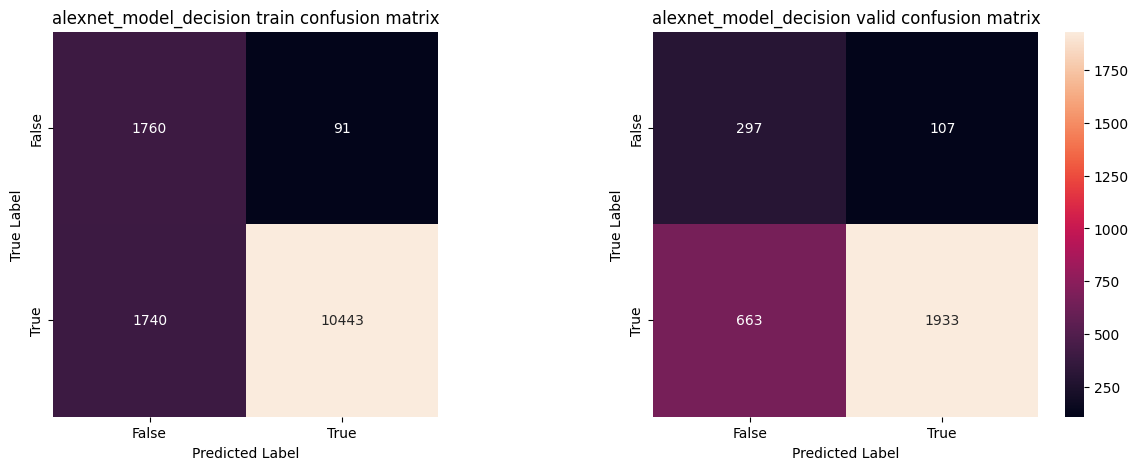

In [112]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision")

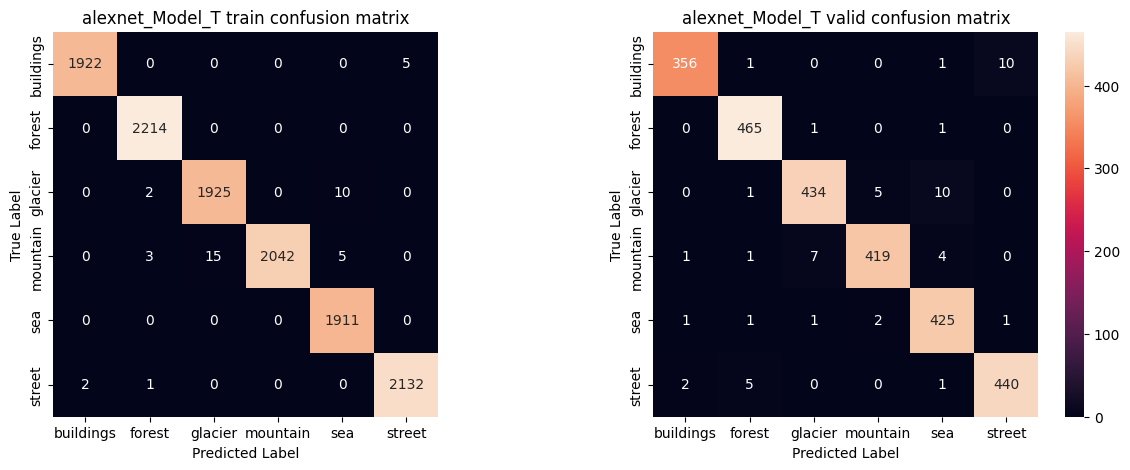

In [113]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T")

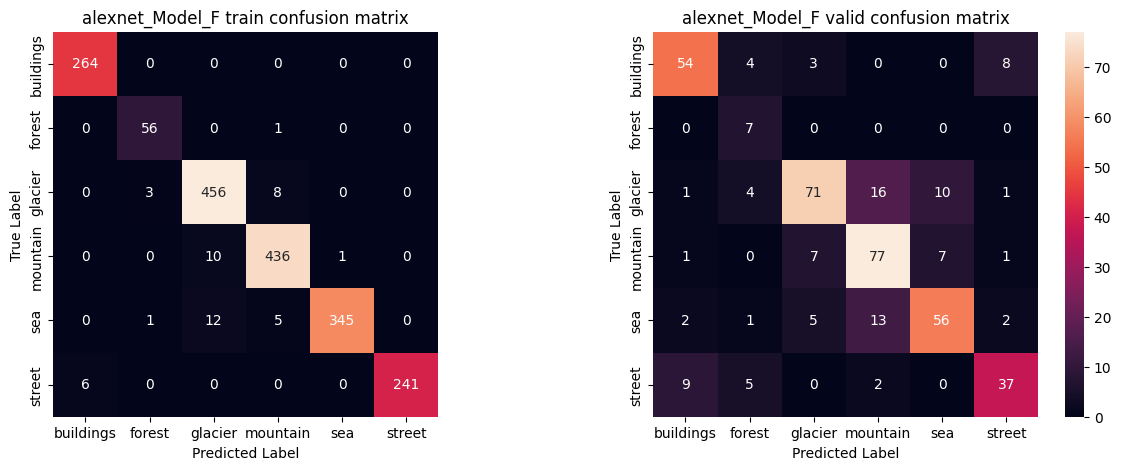

In [114]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F")

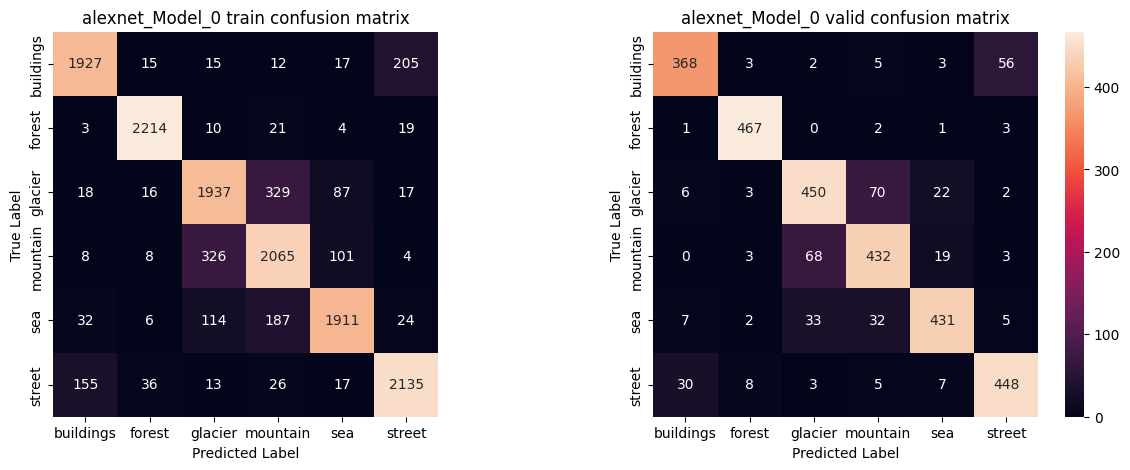

In [115]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0")

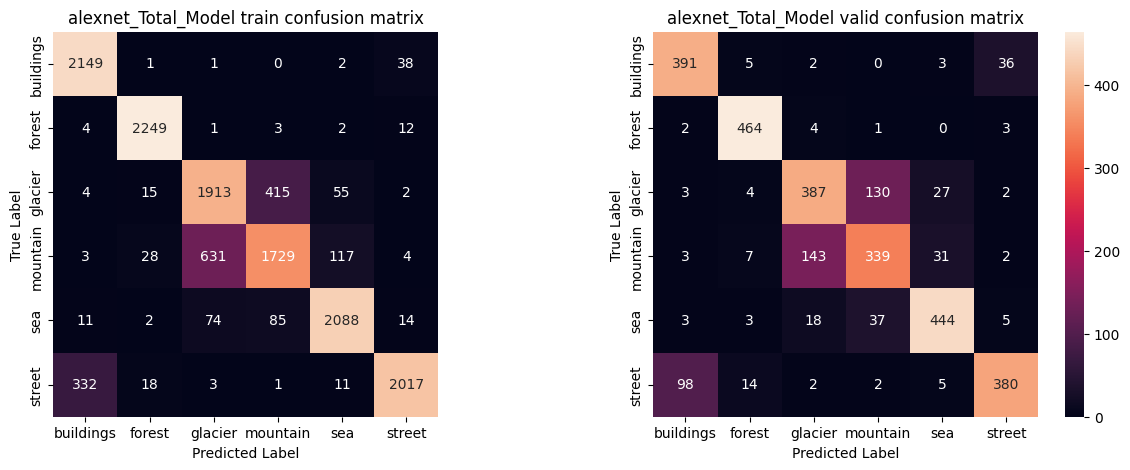

In [116]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model")